# Unit 7 Risk Modelling Activity 1: A Monte Carlo Dice Game

Ian Stevens, Security and Risk Management, Unit 7.

This notebook works through Fizell's (2022) tutorial *How to Create a Monte Carlo Simulation using Python*. The game: a player starts with \$1,000, bets \$1 on each roll of two six-sided dice, and is paid 4 times the bet when both dice show the same number. The player plays 1,000 rolls and the game is simulated 10,000 times.

I rebuilt the simulation in my own code, kept Fizell's inputs so the results can be compared with his, and then added three things the tutorial leaves out:

1. an exact (analytical) check of the simulated answer;
2. the spread of outcomes, not just the average, including the chance that the player ends in profit;
3. how the Monte Carlo error shrinks as the number of runs increases, which matters when a report quotes a confidence interval for a simulated probability.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

random.seed(2026)              # fixed seed so the notebook gives the same numbers every run
rng = np.random.default_rng(2026)
os.makedirs("figures", exist_ok=True)   # saved copies of the charts
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 10)

In [2]:
# Plot style used for every figure in this unit
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

## 1. The simulation

`roll_dice()` rolls two dice and returns `True` when they match. Fizell sets a Boolean flag in an if/else; returning the comparison directly does the same thing.

In [3]:
def roll_dice():
    """Roll two six-sided dice and report whether they show the same number."""
    die_1 = random.randint(1, 6)
    die_2 = random.randint(1, 6)
    return die_1 == die_2

In [4]:
# Inputs (as in Fizell, 2022)
num_simulations = 10_000
max_num_rolls = 1_000
bet = 1
payout = 4            # paid per $1 bet when the dice match
start_balance = 1_000

# Tracking
win_probability = []
end_balance = []
sample_paths = []     # the first 100 games are kept for plotting

In [5]:
for i in range(num_simulations):
    balance = [start_balance]
    num_wins = 0
    for roll in range(max_num_rolls):
        if roll_dice():
            balance.append(balance[-1] + payout * bet)
            num_wins += 1
        else:
            balance.append(balance[-1] - bet)
    win_probability.append(num_wins / max_num_rolls)
    end_balance.append(balance[-1])
    if i < 100:
        sample_paths.append(balance)

end_balance = np.array(end_balance)
print(f"Average win probability after {num_simulations:,} simulations: {np.mean(win_probability):.4f}")
print(f"Average ending balance after {num_simulations:,} simulations: ${end_balance.mean():,.2f}")

Average win probability after 10,000 simulations: 0.1667
Average ending balance after 10,000 simulations: $833.75

These match Fizell's published results (0.1667 and \$833.66) to within the random variation between runs.

Plotting all 10,000 games, as the tutorial does, produces a solid block of colour, so the left panel shows the first 100 games and the right panel shows where all 10,000 finished.

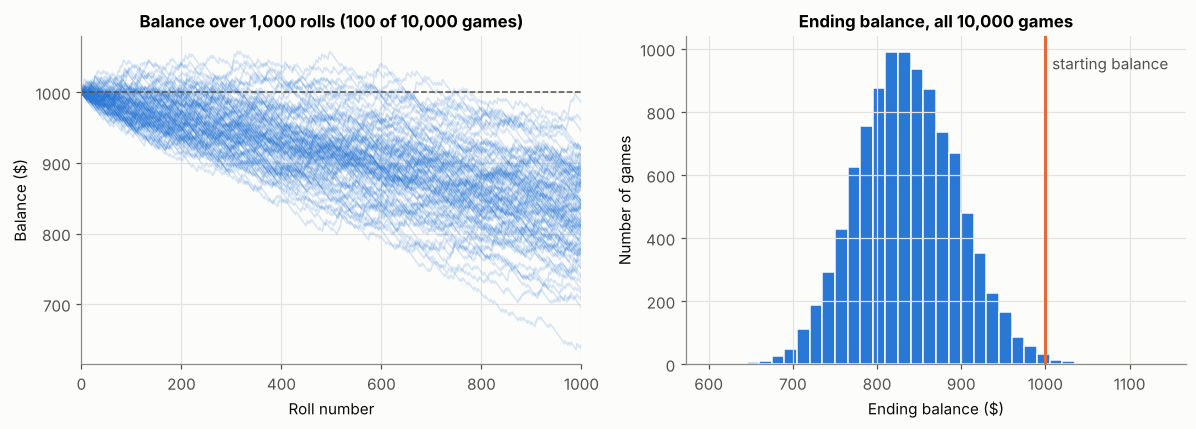

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for path in sample_paths:
    ax1.plot(path, color=BLUE, alpha=0.18, linewidth=1)
ax1.axhline(start_balance, color=INK, linewidth=1, linestyle="--")
ax1.set(title="Balance over 1,000 rolls (100 of 10,000 games)",
        xlabel="Roll number", ylabel="Balance ($)", xlim=(0, max_num_rolls))

ax2.hist(end_balance, bins=np.arange(600, 1150, 15), color=BLUE, edgecolor="#fcfcfb", linewidth=1)
ax2.axvline(start_balance, color=ORANGE, linewidth=2)
ax2.text(start_balance + 8, ax2.get_ylim()[1] * 0.9, "starting balance", color=INK)
ax2.set(title="Ending balance, all 10,000 games", xlabel="Ending balance ($)", ylabel="Number of games")
fig.tight_layout()
fig.savefig("figures/u7_dice_game.png", dpi=150, bbox_inches="tight")

## 2. Checking the answer analytically

Six of the 36 equally likely outcomes are doubles, so the true win probability is 1/6. Each roll is worth $\frac{1}{6}\times 4 - \frac{5}{6}\times 1 = -\frac{1}{6}$ dollars to the player, so the expected ending balance is $1000 - 1000/6 = \$833.33$.

The ending balance is also simple to write down: with $W$ wins it is $1000 + 4W - (1000 - W) = 5W$. The player ends in profit only if $W > 200$, and $W$ follows a binomial distribution with $n = 1000$ and $p = 1/6$, so the probability of a profit can be computed exactly and compared with the simulation.

In [7]:
p = 1 / 6
expected_end = start_balance + max_num_rolls * (p * payout * bet - (1 - p) * bet)
break_even_wins = max_num_rolls * bet / (payout + 1)          # 200 wins
exact_p_profit = stats.binom.sf(break_even_wins, max_num_rolls, p)  # P(W > 200)

summary = pd.DataFrame({
    "Simulated": [np.mean(win_probability), end_balance.mean(), (end_balance > start_balance).mean()],
    "Exact": [p, expected_end, exact_p_profit],
}, index=["Win probability per roll", "Mean ending balance ($)", "P(player ends in profit)"])
summary.round(4)

,Simulated,Exact
Win probability per roll,0.1667,0.1667
Mean ending balance ($),833.7475,833.3333
P(player ends in profit),0.0028,0.0025


In [8]:
pcts = np.percentile(end_balance, [5, 50, 95])
print(f"5th, 50th and 95th percentile ending balance: ${pcts[0]:.0f}, ${pcts[1]:.0f}, ${pcts[2]:.0f}")
print(f"Games ending in profit: {(end_balance > start_balance).sum()} of {num_simulations:,}")

5th, 50th and 95th percentile ending balance: $740, $830, $935
Games ending in profit: 28 of 10,000

The average hides the most useful result. Only about 1 game in 400 ends in profit, and 90% of games finish between about \$740 and \$935. For a risk decision the spread and the tail are what matter, and Fizell's two summary numbers do not report either.

## 3. Changing the payout

Fizell ends by saying that a payout of 5 times the bet would let the player break even on average. The table below tests 4, 5 and 6 times the bet. Because the number of wins in a game is binomial, each game can be simulated with a single binomial draw instead of 1,000 dice rolls, which gives the same distribution far faster.

In [9]:
rows = []
for k in [4, 5, 6]:
    wins = rng.binomial(max_num_rolls, p, size=num_simulations)
    end = start_balance + wins * k * bet - (max_num_rolls - wins) * bet
    rows.append({
        "Payout": f"{k} x bet",
        "Expected ending balance ($)": start_balance + max_num_rolls * (p * k - (1 - p)),
        "Simulated mean ($)": end.mean(),
        "P(player ends in profit)": (end > start_balance).mean(),
        "5th percentile ($)": np.percentile(end, 5),
    })
pd.DataFrame(rows).set_index("Payout").round(3)

,Expected ending balance ($),Simulated mean ($),P(player ends in profit),5th percentile ($)
Payout,,,,
4 x bet,833.333,833.921,0.003,735.0
5 x bet,1000.000,999.254,0.491,882.0
6 x bet,1166.667,1166.707,0.981,1029.0


At 5 times the bet the expected balance is exactly \$1,000, but the chance of ending in profit is a little under one half because a game can also end level. Even in this fair game about 1 player in 20 finishes more than \$110 down after 1,000 rolls, and at 6 times the bet the player ends ahead in about 98% of games, which is Fizell's point about the house going bankrupt.

## 4. How accurate is a Monte Carlo estimate?

A Monte Carlo estimate of a probability $p$ from $n$ independent runs has a standard error of $\sqrt{p(1-p)/n}$. The error therefore shrinks with the square root of the number of runs: 100 times as many runs buys only 10 times the precision.

In [10]:
rows = []
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    dice = rng.integers(1, 7, size=(n, 2))
    est = np.mean(dice[:, 0] == dice[:, 1])
    se = np.sqrt(est * (1 - est) / n)
    rows.append({"Runs": f"{n:,}", "Estimate of P(double)": est,
                 "95% margin (+/-)": 1.96 * se, "Actual error": abs(est - p)})
pd.DataFrame(rows).set_index("Runs").round(5)

,Estimate of P(double),95% margin (+/-),Actual error
Runs,,,
100,0.15000,0.06999,0.01667
"1,000",0.15900,0.02266,0.00767
"10,000",0.16610,0.00729,0.00057
"100,000",0.16631,0.00231,0.00036
"1,000,000",0.16675,0.00073,0.00009


This interval describes **sampling error in the simulation only**. It says nothing about whether the inputs are right. Here the inputs are known exactly (a fair die has probability 1/6 per face), so the interval is the whole story. In a risk model whose inputs are expert estimates, a tight interval from a large number of runs can look more certain than the model deserves. I come back to this in the Pampered Pets notebook.

## Reference

Fizell, Z. (2022) *How to create a Monte Carlo simulation using Python*. Towards Data Science, 8 February. Available at: https://towardsdatascience.com/how-to-create-a-monte-carlo-simulation-using-python-c24634a0978a/